In [1]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np

In [2]:
data = fetch_california_housing(as_frame=True)
X = data.data.drop(columns=['MedInc'])
y = data.target
X.head()

,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [3]:
X.isna().sum()

HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64

In [4]:
from sklearn.model_selection import train_test_split
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.25, random_state=1)
from sklearn.tree import DecisionTreeRegressor
model_dt = DecisionTreeRegressor()
model_dt.fit(Xtrain, ytrain)



DecisionTreeRegressor()

In [5]:
pred_dt = model_dt.predict(Xtest)
from sklearn.metrics import mean_squared_error
mean_squared_error(ytest, pred_dt)

0.48665468854306204

In [6]:
from sklearn.ensemble import RandomForestRegressor
model_rf = RandomForestRegressor()
model_rf.fit(Xtrain, ytrain)


RandomForestRegressor()

In [7]:
pred_rf = model_rf.predict(Xtest)
mean_squared_error(ytest, pred_rf)

0.23866302827684077

Ошибка у леса в два раза меньше, чем у дерева!


Теперь изучим гиперпараметры леса.

In [16]:
?RandomForestRegressor

Init signature:
RandomForestRegressor(
    n_estimators=100,
    *,
    criterion='squared_error',
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    min_weight_fraction_leaf=0.0,
    max_features=1.0,
    max_leaf_nodes=None,
    min_impurity_decrease=0.0,
    bootstrap=True,
    oob_score=False,
    n_jobs=None,
    random_state=None,
    verbose=0,
    warm_start=False,
    ccp_alpha=0.0,
    max_samples=None,
    monotonic_cst=None,
)
Docstring:     
A random forest regressor.

A random forest is a meta estimator that fits a number of decision tree
regressors on various sub-samples of the dataset and uses averaging to
improve the predictive accuracy and control over-fitting.
Trees in the forest use the best split strategy, i.e. equivalent to passing
`splitter="best"` to the underlying :class:`~sklearn.tree.DecisionTreeRegressor`.
The sub-sample size is controlled with the `max_samples` parameter if
`bootstrap=True` (default), otherwise the whole dataset is use

- n_estimators — число деревьев;
- criterion — критерий информативности для построения дерева;
- max_depth — глубина деревьев в лесу;
- min_samples_split — минимальное число объектов, необходимое для
разбиения вершины;
- min_samples_leaf — минимальное число объектов в вершине, для того
чтобы она была листом;
- max_features — максимальное число признаков, из которых ищем
наилучшее разбиение на каждом шаге построения дерева;
- max_samples — максимальное количество объектов в подвыборке,
сформированной при помощи бутстрепа из исходной выборки.

In [8]:
N = []
MSE = []
for n in np.arange(10, 120, 20):
    rf = RandomForestRegressor(n_estimators = n)
    rf.fit(Xtrain, ytrain)
    pred_rf = rf.predict(Xtest)
    N.append(n)
    MSE.append(mean_squared_error(ytest, pred_rf))


Text(0, 0.5, 'MSE on test')

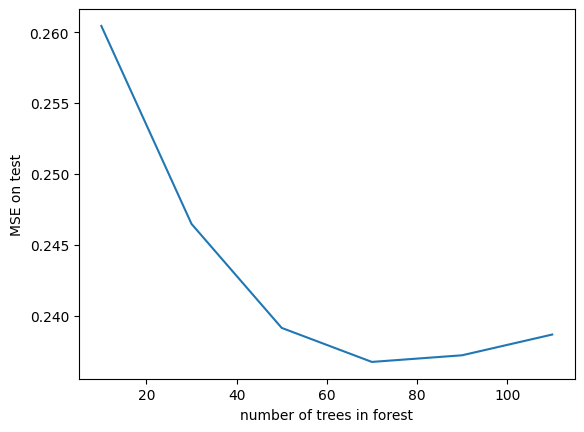

In [10]:
from matplotlib import pyplot as plt
plt.plot(N, MSE, '-')
plt.xlabel('number of trees in forest')
plt.ylabel('MSE on test')


Мы наблюдаем важную зависимость, и это неплохо запомнить: случайный лес не
переобучается с увеличением числа деревьев!
То есть чем больше деревьев в лесу, тем меньше будет ошибка на тестовых данных.
Однако начиная с какого-то числа деревьев ошибка уменьшается совсем
незначительно, а при дальнейшем увеличении числа деревьев скорость обучения
алгоритма падает.
Поэтому обычно выбирают минимальное число деревьев в лесу, при котором
ошибка на тесте перестаёт сильно убывать.
Возьмём 100 деревьев в лесу, так как при 100 деревьях ошибка убывает уже
несильно. Теперь будем перебирать глубину деревьев аналогичным образом.


In [11]:
D = []
MSE = []
for d in np.arange(2, 50, 5):
    rf = RandomForestRegressor(n_estimators = 70, max_depth = d)
    rf.fit(Xtrain, ytrain)
    pred_rf = rf.predict(Xtest)
    D.append(d)
    MSE.append(mean_squared_error(ytest, pred_rf))


Text(0, 0.5, 'MSE on test')

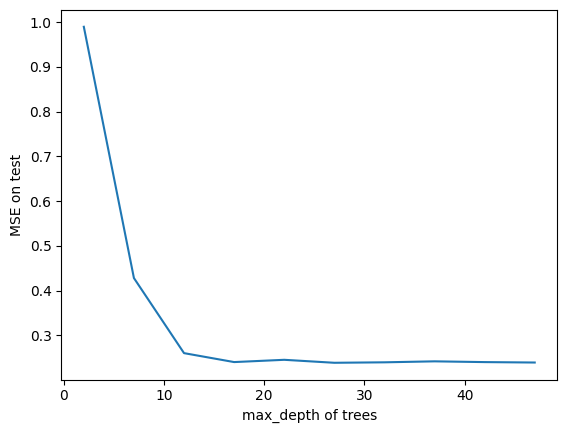

In [12]:
plt.plot(D, MSE, '-')
plt.xlabel('max_depth of trees')
plt.ylabel('MSE on test')

Мы видим, что сначала при увеличении глубины деревьев ошибка падает, а затем,
примерно с глубины 20, ошибка начинает расти, то есть начинается переобучение.
Значит, для леса со 100 деревьями надо брать деревья максимальной глубины — 20.
Проверим, каких значений метрики удастся достичь при обучении случайного леса
с найденными значениями гиперпараметров.


In [16]:
model_rf = RandomForestRegressor(n_estimators = 70, max_depth = 18)
model_rf.fit(Xtrain, ytrain)
pred_rf = model_rf.predict(Xtest)
mean_squared_error(ytest, pred_rf)

0.23890802194269417

In [41]:
pred_rf

array([3.51715327, 0.63510641, 2.35184667, ..., 0.72187414, 2.34444683,
       1.49467509])

In [71]:
df1=Xtest

In [72]:
df1['MedHouseVal']=ytest

In [73]:
df1['PredVal']=pred_rf

In [74]:
df1

,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,PredVal
4712,39.0,4.503205,1.073718,1109.0,1.777244,34.06,-118.36,3.550,4.008062
2151,37.0,4.988584,1.038813,1143.0,2.609589,36.78,-119.78,0.707,0.653850
15927,46.0,4.480296,1.012315,1534.0,3.778325,37.73,-122.42,2.294,2.296530
82,52.0,3.908046,1.114943,200.0,2.298851,37.81,-122.28,1.125,1.276350
8161,37.0,5.406360,1.024735,711.0,2.512367,33.82,-118.13,2.254,2.168910
...,...,...,...,...,...,...,...,...,...
20073,47.0,5.170732,1.068293,496.0,2.419512,37.97,-120.38,1.048,0.929210
16471,25.0,5.553191,1.148936,789.0,3.357447,38.13,-121.25,0.911,1.147570
3050,16.0,5.910448,1.152985,1011.0,3.772388,35.60,-119.34,0.588,0.769010
8003,36.0,5.529221,1.055195,845.0,2.743506,33.86,-118.14,2.108,2.157520


In [ ]:
df1['MedHouseVal'].count()

5160

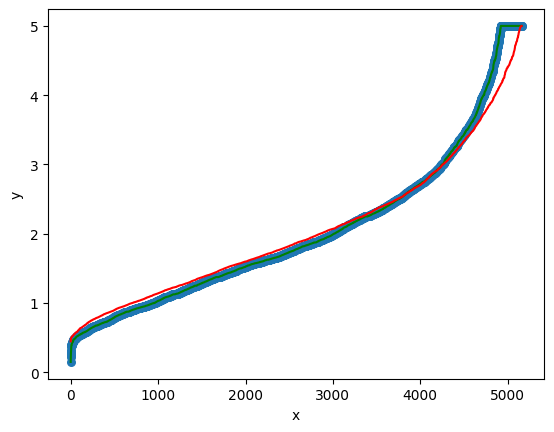

In [78]:
x=range(df1['PredVal'].count())
y=df1['MedHouseVal'].sort_values(ascending=True)
y1=df1['PredVal'].sort_values(ascending=True)
#y2=df1['MedInc'].sort_values(ascending=True)
plt.scatter(x, y, s=30)
plt.plot(x, y, 'g')
plt.plot(x, y1, 'r')
#plt.plot(x, y2, 'b')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [79]:
from sklearn.tree import plot_tree

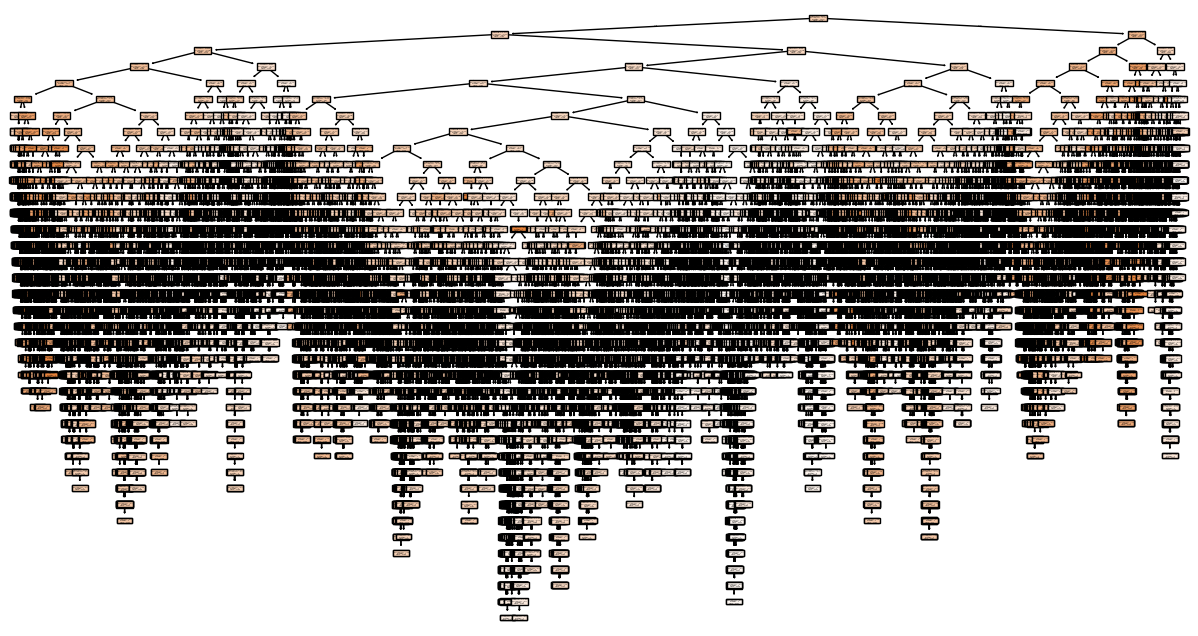

In [81]:
plt.figure(figsize=(15, 8))
plot_tree(model_dt, feature_names=df1.columns[:-1], filled=True)
plt.show()

In [27]:
data.data

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [28]:
data.target

0        4.526
1        3.585
2        3.521
3        3.413
4        3.422
         ...  
20635    0.781
20636    0.771
20637    0.923
20638    0.847
20639    0.894
Name: MedHouseVal, Length: 20640, dtype: float64

In [ ]:
df=data.data


In [30]:
df['MedHouseVal']=data.target

In [31]:
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


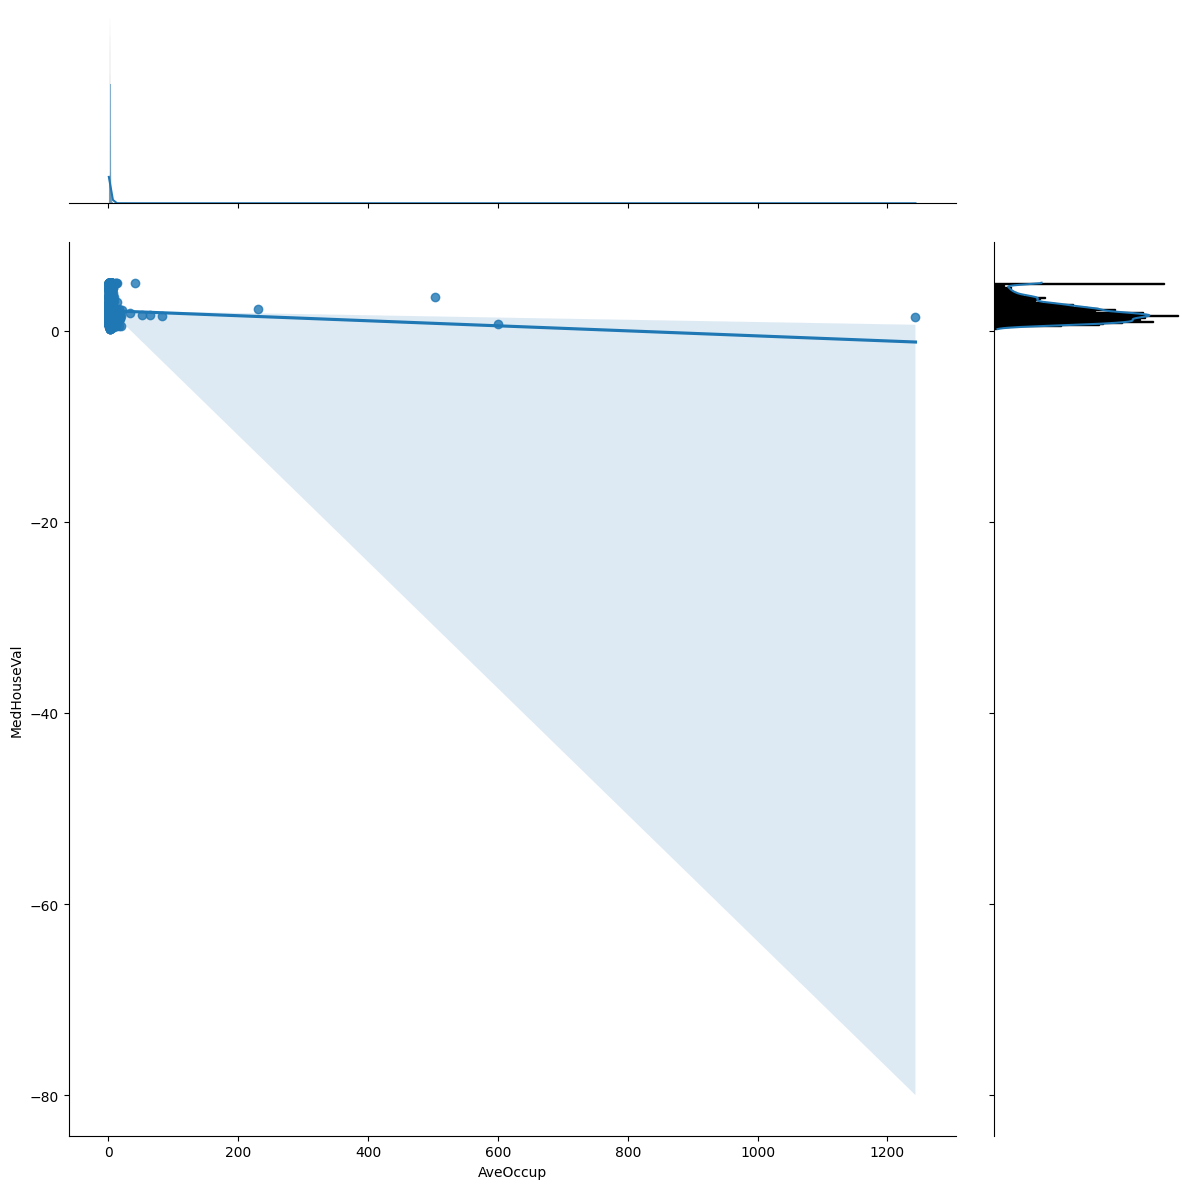

In [34]:
import seaborn as sns
# Зависимость цены от жилой зоны
sns.jointplot(data=df, x='AveOccup', y='MedHouseVal', kind="reg", height=12, ratio=4);

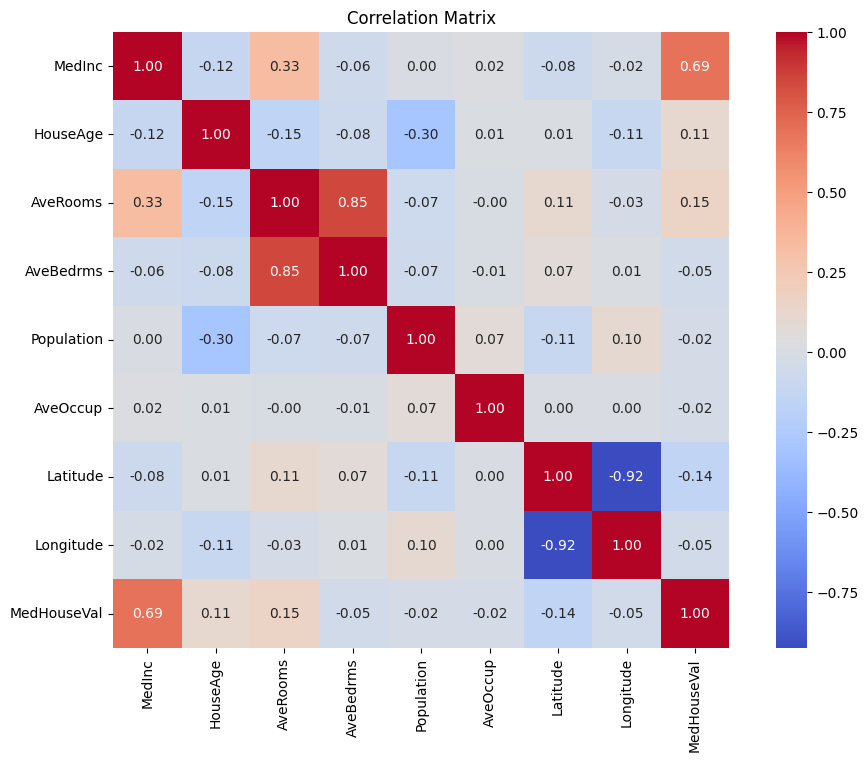

In [35]:
# Построение матрицы корреляции
correlation_matrix = df.corr()

# Настройка размера графика
plt.figure(figsize=(12, 8))

# Построение тепловой карты корреляции
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True, cbar=True)

# Заголовок и отображение
plt.title('Correlation Matrix')
plt.show()


In [37]:
def analyze_df(df):
    # Количество строк и столбцов
    rows_count, columns_count = df.shape
    print('Количество столбцов:', columns_count)
    print('Количество строк:', rows_count)

    # Первые 5 строк
    display(df.head(5))

    # Статистическое описание
    display(df.describe())

    # Информация о данных
    df.info()

    # Типы данных
    print("\nТипы данных:")
    print(df.dtypes)

    # Обнаружение дубликатов
    duplicates_count = df.duplicated().sum()
    print('\nКоличество дубликатов:', duplicates_count)

    # Обнаружение пропущенных значений
    missing_values = df.isnull().sum()
    print('\nПропущенные значения (по столбцам):')
    print(missing_values)

    # Общее пропущенных значений
    total_missing = missing_values.sum()
    print('\nОбщее количество пропущенных значений:', total_missing)

    # Уникальные значения
    print('\nУникальные значения (по столбцам):')
    print(df.nunique())

    # Гистограммы для числовых признаков
    if not df.select_dtypes(include=[float, int]).empty:
        df.select_dtypes(include=[float, int]).hist(bins=15, figsize=(15, 10))
        plt.suptitle('Гистограммы числовых признаков')
        plt.show()
    else:
        print("\nНет числовых данных для построения гистограмм.")

    # Матрица корреляции
    numeric_df = df.select_dtypes(include=[float, int])
    if not numeric_df.empty:
        correlation_matrix = numeric_df.corr()
        plt.figure(figsize=(10, 8))
        sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')
        plt.title('Матрица корреляции числовых признаков')
        plt.show()
    else:
        print("\nНет числовых данных для построения матрицы корреляции.")

Количество столбцов: 9
Количество строк: 20640


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB

Типы данных:
MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object

Количество дубликатов: 0

Пропущенные значения (по столбцам):
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccu

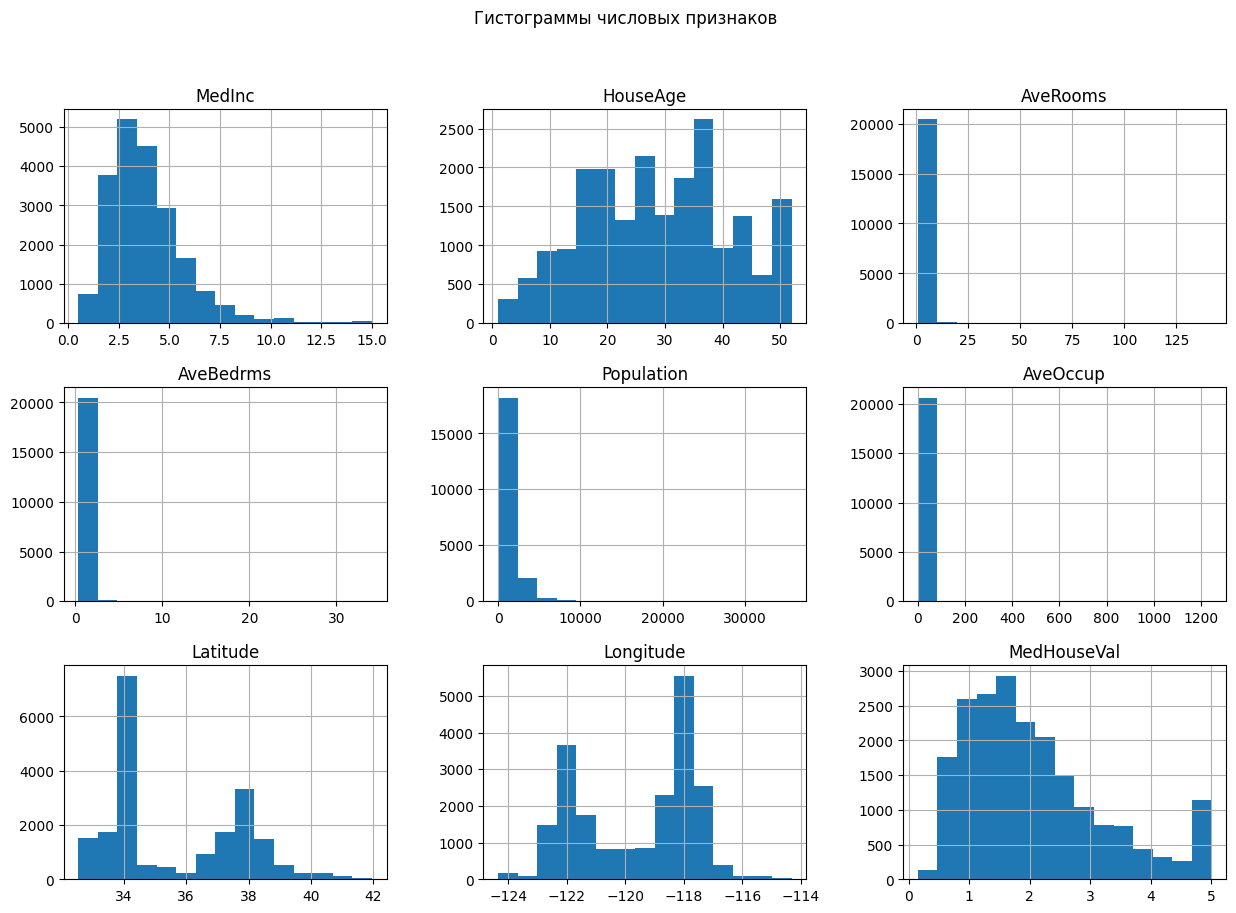

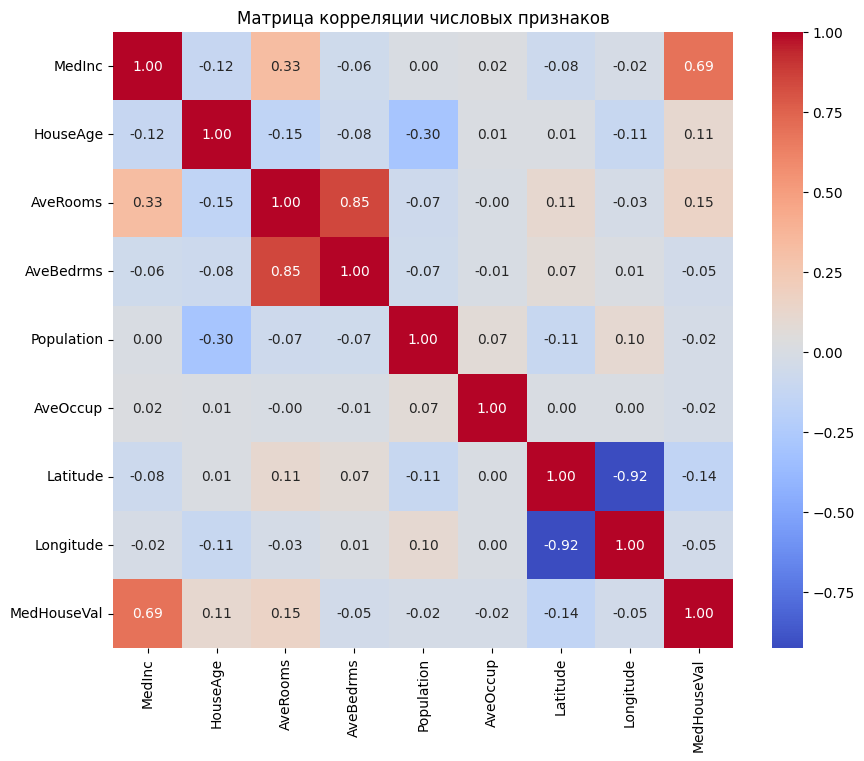

In [38]:
analyze_df(df)